# WildTrace Pipeline Driver

This notebook is the current driver for the agentic WildTrace pipeline. It runs the DAG-style stage scripts in order so we can inspect outputs while keeping the same script boundaries that Airflow will use later.

Before running the notebook:
- run `uv sync` from the repo root
- start Ollama with `ollama serve`
- pull the configured local models
- make sure BioCLIP runs on a CUDA-capable GPU machine for bronze enrichment
- create `.env` from `.env.example` if you need custom model or host settings


In [14]:
from collections import Counter
from pathlib import Path
import json
import subprocess

import yaml
from IPython.display import SVG, display
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "scripts").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "scripts").exists() and (parent / "configs").exists():
            REPO_ROOT = parent
            break

SCRIPTS_DIR = REPO_ROOT / 'scripts'
CONFIG_DIR = REPO_ROOT / 'configs'
PYTHON = REPO_ROOT / '.venv' / 'bin' / 'python'

if not PYTHON.exists():
    raise FileNotFoundError(f"{PYTHON} not found. Run `uv sync` from {REPO_ROOT} first.")

print("repo_root =", REPO_ROOT)
print("python =", PYTHON)
print("scripts_dir =", SCRIPTS_DIR)
print("config_dir =", CONFIG_DIR)

RUN_FETCH_IDEMPOTENCY_CHECK = False
print('RUN_FETCH_IDEMPOTENCY_CHECK =', RUN_FETCH_IDEMPOTENCY_CHECK)


repo_root = /home/shra012/Workspace/WildTrace
python = /home/shra012/Workspace/WildTrace/.venv/bin/python
scripts_dir = /home/shra012/Workspace/WildTrace/scripts
config_dir = /home/shra012/Workspace/WildTrace/configs
RUN_FETCH_IDEMPOTENCY_CHECK = False


In [15]:
def run_stage(script_name: str):
    script = SCRIPTS_DIR / script_name
    cmd = [str(PYTHON), str(script), '--repo-root', str(REPO_ROOT), '--config-dir', str(CONFIG_DIR)]
    print('Running:', ' '.join(cmd))
    return subprocess.run(cmd, check=True)


def load_ndjson(path: Path):
    if not path.exists():
        return []
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]

## Inspect Configs

Tune these first before running a larger fetch.

In [16]:
for name in ['datasets.yaml', 'storage.yaml', 'quality.yaml', 'viewpoints.yaml', 'models.yaml', 'export.yaml']:
    path = CONFIG_DIR / name
    print(f'\n## {name}')
    print(yaml.safe_dump(yaml.safe_load(path.read_text()), sort_keys=False))


## datasets.yaml
task_type: drawing
source_dataset: openimages
categories:
- name: Cat
  limit: 100
- name: Dog
  limit: 100
- name: Horse
  limit: 100
- name: Bird
  limit: 100
- name: Butterfly
  limit: 100
- name: Fish
  limit: 100
fetch:
  source_mode: official
  records_path: null
  records: []
  timeout_seconds: 30
  user_agent: WildTraceETL/0.1
  manifest_path: outputs/bronze/manifests/openimages_fetch.ndjson
  latest_view_path: outputs/bronze/manifests/openimages_fetch_latest.ndjson
  official:
    splits:
    - train
    - validation
    require_masks: true
    class_descriptions_url: https://storage.googleapis.com/openimages/v7/oidv7-class-descriptions-boxable.csv
    image_base_url_template: https://open-images-dataset.s3.amazonaws.com/{split}/{image_id}.jpg
    image_info_urls:
      train: https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv
      validation: https://storage.googleapis.com/openimages/2018_04/validation/validation-

## Step 1: Fetch Open Images

In [17]:
run_stage('fetch_openimages.py')

fetch_ledger = REPO_ROOT / 'outputs' / 'bronze' / 'manifests' / 'openimages_fetch.ndjson'
fetch_latest = REPO_ROOT / 'outputs' / 'bronze' / 'manifests' / 'openimages_fetch_latest.ndjson'
fetch_rows = load_ndjson(fetch_ledger)
fetch_latest_rows = load_ndjson(fetch_latest)
print('fetch ledger rows =', len(fetch_rows))
print('fetch latest rows =', len(fetch_latest_rows))
fetch_latest_rows[:3]

Running: /home/shra012/Workspace/WildTrace/.venv/bin/python /home/shra012/Workspace/WildTrace/scripts/fetch_openimages.py --repo-root /home/shra012/Workspace/WildTrace --config-dir /home/shra012/Workspace/WildTrace/configs
fetch ledger rows = 839
fetch latest rows = 471


[{'asset_version': 2,
  'category': 'Bird',
  'failure_reason': None,
  'fetch_status': 'success',
  'fetched_at': '2026-04-05T03:07:48.150724+00:00',
  'image_checksum': '0ecd767fef243f95fd5ee198eef4287d868a4593474df88e567b64c62b3cb673',
  'image_path': 'outputs/bronze/images/Bird/052f30216bc7427f/v0002.jpg',
  'image_uri': 'local://outputs/bronze/images/Bird/052f30216bc7427f/v0002.jpg',
  'license': 'https://creativecommons.org/licenses/by/2.0/',
  'mask_archive_url': 'https://storage.googleapis.com/openimages/v5/train-masks/train-masks-6.zip',
  'mask_checksum': 'ed357ba80082398b463fe061ad3697afff307579c9ac1829b8da71ea2aded62e',
  'mask_path': 'outputs/bronze/masks/Bird/052f30216bc7427f/v0002.png',
  'mask_path_in_archive': '60ccd324d6d410f2_m015p6_9634a2c8.png',
  'mask_source_url': None,
  'mask_uri': 'local://outputs/bronze/masks/Bird/052f30216bc7427f/v0002.png',
  'metadata_path': 'outputs/bronze/metadata/Bird/052f30216bc7427f/v0002.json',
  'record_id': 'a740c798fa9ad307',
  's

### Bronze Cache Check

These cells help us verify that bronze fetch is reusing existing downloaded assets instead of downloading the same files again.


In [18]:
fetch_versions = Counter(row['asset_version'] for row in fetch_rows)
latest_versions = Counter(row['asset_version'] for row in fetch_latest_rows)
duplicate_latest_image_paths = [path for path, count in Counter(row['image_path'] for row in fetch_latest_rows).items() if count > 1]
duplicate_latest_mask_paths = [path for path, count in Counter(row['mask_path'] for row in fetch_latest_rows if row.get('mask_path')).items() if count > 1]

print('fetch ledger rows =', len(fetch_rows))
print('latest success rows =', len(fetch_latest_rows))
print('asset version distribution =', dict(fetch_versions))
print('latest version distribution =', dict(latest_versions))
print('duplicate latest image paths =', len(duplicate_latest_image_paths))
print('duplicate latest mask paths =', len(duplicate_latest_mask_paths))
print('reused existing bronze assets =', len(fetch_rows) == len(fetch_latest_rows) and max(fetch_versions or {0: 0}) == 1)

if duplicate_latest_image_paths:
    duplicate_latest_image_paths[:10]


fetch ledger rows = 839
latest success rows = 471
asset version distribution = {1: 529, 2: 310}
latest version distribution = {2: 310, 1: 161}
duplicate latest image paths = 0
duplicate latest mask paths = 0
reused existing bronze assets = False


In [19]:
if RUN_FETCH_IDEMPOTENCY_CHECK:
    fetch_rows_before = load_ndjson(fetch_ledger)
    run_stage('fetch_openimages.py')
    fetch_rows_after = load_ndjson(fetch_ledger)
    new_rows = len(fetch_rows_after) - len(fetch_rows_before)
    print('new fetch ledger rows after rerun =', new_rows)
    if new_rows == 0:
        print('No new downloads were needed. Bronze fetch reused existing assets.')
    else:
        print('Fetch added new ledger rows; inspect version bumps or source changes.')
else:
    print('Idempotency rerun skipped. Set RUN_FETCH_IDEMPOTENCY_CHECK = True to rerun fetch and verify no extra downloads.')


Idempotency rerun skipped. Set RUN_FETCH_IDEMPOTENCY_CHECK = True to rerun fetch and verify no extra downloads.


## Step 2: Curate Bronze

In [20]:
run_stage('curate_bronze.py')

bronze_curated = REPO_ROOT / 'outputs' / 'bronze' / 'manifests' / 'bronze_curated.ndjson'
bronze_accepted = REPO_ROOT / 'outputs' / 'bronze' / 'manifests' / 'bronze_accepted.ndjson'
curated_rows = load_ndjson(bronze_curated)
accepted_rows = load_ndjson(bronze_accepted)
print('bronze curated rows =', len(curated_rows))
print('bronze accepted rows =', len(accepted_rows))
accepted_rows[:3]

Running: /home/shra012/Workspace/WildTrace/.venv/bin/python /home/shra012/Workspace/WildTrace/scripts/curate_bronze.py --repo-root /home/shra012/Workspace/WildTrace --config-dir /home/shra012/Workspace/WildTrace/configs
bronze curated rows = 471
bronze accepted rows = 161


[{'angle_bucket': 'left_profile',
  'angle_feasible': True,
  'category': 'Cat',
  'curation_flags': [],
  'curation_status': 'accepted',
  'deleted_paths': [],
  'image_checksum': '241018ce4f3e2d2bb59d341d74954545a549fd908fc3cb44a39cabc37e365d00',
  'image_path': 'outputs/bronze/images/Cat/01a6f4902a05f148/v0001.jpg',
  'image_uri': 'local://outputs/bronze/images/Cat/01a6f4902a05f148/v0001.jpg',
  'label_confidence': 0.7223939299583435,
  'label_source': 'imageomics/bioclip',
  'lineage': {'bronze_config_hash': '0b23aff67844081b',
   'curated_at': '2026-04-04T21:25:39.284948+00:00',
   'enrichment_model': {'cache_dir': '/home/shra012/.cache/huggingface',
    'candidate_labels': ['cat', 'domestic cat'],
    'device': 'cuda',
    'model_backend': 'huggingface',
    'model_id': 'imageomics/bioclip',
    'model_name': 'imageomics/bioclip'},
   'fetch_record_id': '5fad37a8d9d8b4fd'},
  'mask_path': 'outputs/bronze/masks/Cat/01a6f4902a05f148/v0001.png',
  'mask_uri': 'local://outputs/bronze

In [21]:
from collections import Counter

flag_counts = Counter()
for row in curated_rows:
    for flag in row.get('curation_flags', []):
        flag_counts[flag] += 1

accepted_by_cat = Counter(r['category'] for r in curated_rows if r['curation_status'] == 'accepted')
rejected_by_cat = Counter(r['category'] for r in curated_rows if r['curation_status'] == 'rejected')

print(f'total curated: {len(curated_rows)}')
print(f'accepted:      {len(accepted_rows)}')
print(f'rejected:      {len(curated_rows) - len(accepted_rows)}')
print()
print('rejection flags:')
for flag, count in flag_counts.most_common():
    print(f'  {flag}: {count}')
print()
print('accepted by category:', dict(accepted_by_cat))
print('rejected by category:', dict(rejected_by_cat))


total curated: 471
accepted:      161
rejected:      310

rejection flags:
  low_mask_coverage: 157
  top_heavy_pose: 128
  low_blur_variance: 78
  low_margin: 22
  low_confidence: 13
  low_largest_component_ratio: 11
  duplicate_image_checksum: 6
  high_border_touch_ratio: 4
  too_many_components: 1

accepted by category: {'Cat': 44, 'Dog': 44, 'Horse': 38, 'Bird': 22, 'Fish': 13}
rejected by category: {'Fish': 80, 'Dog': 50, 'Bird': 72, 'Cat': 51, 'Horse': 57}


In [22]:
# Show up to 4 rejected images with their flags for a quick sanity-check.
rejected_rows = [r for r in curated_rows if r['curation_status'] == 'rejected']
for row in rejected_rows[:4]:
    img_path = REPO_ROOT / row['image_path']
    flags = ', '.join(row['curation_flags'])
    print(f"{row['sample_id']} | {row['category']} | {row.get('angle_bucket','?')} | flags: {flags}")
    if img_path.exists():
        display(Image.open(img_path).resize((256, 256), Image.Resampling.LANCZOS))


01697dc3eddfea7b | Fish | unknown | flags: low_mask_coverage
020d9a4de121112b | Fish | unknown | flags: low_blur_variance
02ce63d7ea855eef | Fish | unknown | flags: low_blur_variance
02de6ed8f5e0ae1f | Dog | unknown | flags: top_heavy_pose


## Step 3: Normalize To Silver

In [23]:
run_stage('normalize_to_silver.py')

silver_path = REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'silver_samples.ndjson'
silver_rows = load_ndjson(silver_path)
silver_rows[:2]

Running: /home/shra012/Workspace/WildTrace/.venv/bin/python /home/shra012/Workspace/WildTrace/scripts/normalize_to_silver.py --repo-root /home/shra012/Workspace/WildTrace --config-dir /home/shra012/Workspace/WildTrace/configs


[{'angle_bucket': 'left_profile',
  'angle_feasible': True,
  'blur_score': 0.0021860201377421618,
  'category': 'Cat',
  'grayscale_detected': False,
  'grayscale_path': 'outputs/silver/images/Cat/01a6f4902a05f148_gray.png',
  'image_path': 'outputs/silver/images/Cat/01a6f4902a05f148_rgb.png',
  'isolated_path': 'outputs/silver/isolated_subjects/Cat/01a6f4902a05f148_isolated.png',
  'label_confidence': 0.7223939299583435,
  'label_source': 'imageomics/bioclip',
  'lineage': {'bronze_input_hash': 'eee72a9428258739',
   'bronze_sample_id': '01a6f4902a05f148',
   'silver_config_hash': '6ac55c46dea589c5'},
  'mask_coverage_ratio': 0.06270823759191177,
  'mask_path': 'outputs/silver/masks/Cat/01a6f4902a05f148_mask.png',
  'quality_flags': [],
  'quality_status': 'accepted',
  'sample_id': '01a6f4902a05f148',
  'subcategory': 'cat',
  'tags': ['bioclip_enrichment',
   'cat',
   'domestic_cat',
   'drawable_subject',
   'left_profile',
   'photo_source',
   'segmented',
   'train',
   'wide'

## Step 4: Enrich And Crop Subjects

In [24]:
run_stage('enrich_and_crop_subjects.py')

subjects_path = REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'silver_subjects.ndjson'
subject_rows = load_ndjson(subjects_path)
subject_rows[:2]

Running: /home/shra012/Workspace/WildTrace/.venv/bin/python /home/shra012/Workspace/WildTrace/scripts/enrich_and_crop_subjects.py --repo-root /home/shra012/Workspace/WildTrace --config-dir /home/shra012/Workspace/WildTrace/configs


[{'angle_bucket': 'left_profile',
  'angle_feasible': True,
  'blur_score': 0.0021860201377421618,
  'category': 'Cat',
  'crop_bbox': {'bottom': 598, 'left': 167, 'right': 599, 'top': 166},
  'crop_path': 'outputs/silver/crops/Cat/01a6f4902a05f148_crop.png',
  'grayscale_detected': False,
  'grayscale_path': 'outputs/silver/images/Cat/01a6f4902a05f148_gray.png',
  'image_path': 'outputs/silver/images/Cat/01a6f4902a05f148_rgb.png',
  'isolated_path': 'outputs/silver/isolated_subjects/Cat/01a6f4902a05f148_isolated.png',
  'label_confidence': 0.7223939299583435,
  'label_source': 'imageomics/bioclip',
  'lineage': {'bronze_input_hash': 'eee72a9428258739',
   'bronze_sample_id': '01a6f4902a05f148',
   'silver_config_hash': '6ac55c46dea589c5',
   'silver_input_hash': '325b5bcfd65faffa',
   'subject_config_hash': '6ac55c46dea589c5',
   'subject_stage': 'enrich_and_crop_subjects'},
  'mask_coverage_ratio': 0.06270823759191177,
  'mask_path': 'outputs/silver/masks/Cat/01a6f4902a05f148_mask.pn

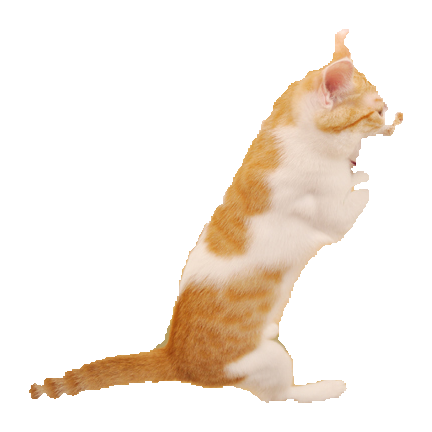

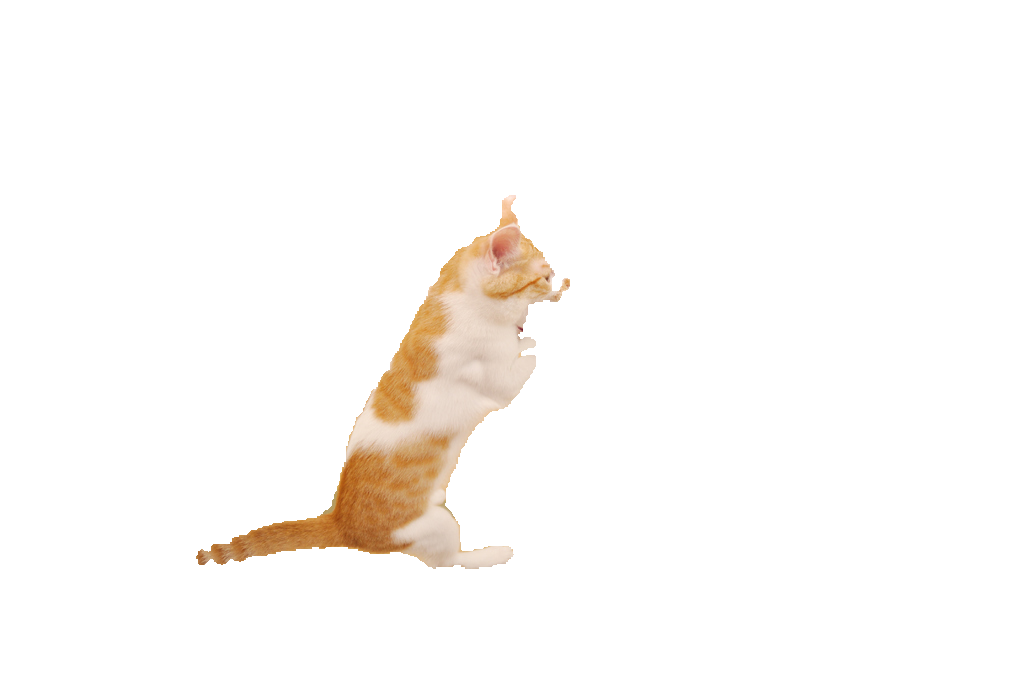

In [25]:
if subject_rows:
    sample = subject_rows[0]
    display(Image.open(REPO_ROOT / sample['crop_path']))
    if sample['isolated_path']:
        display(Image.open(REPO_ROOT / sample['isolated_path']))

## Step 5: Generate Line Diagrams

In [ ]:
run_stage('generate_line_diagrams.py')

diagram_attempts_path = REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'line_diagram_attempts.ndjson'
diagram_attempt_rows = load_ndjson(diagram_attempts_path)
diagram_attempt_rows[:2]

Running: /home/shra012/Workspace/WildTrace/.venv/bin/python /home/shra012/Workspace/WildTrace/scripts/generate_line_diagrams.py --repo-root /home/shra012/Workspace/WildTrace --config-dir /home/shra012/Workspace/WildTrace/configs


/home/shra012/Workspace/WildTrace/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
  0%|          | 0/4 [00:00<?, ?it/s]

Dog / dog / left_profile


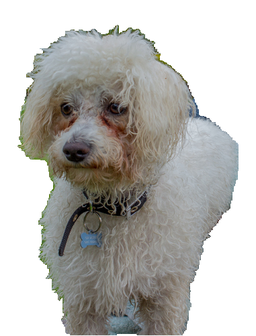

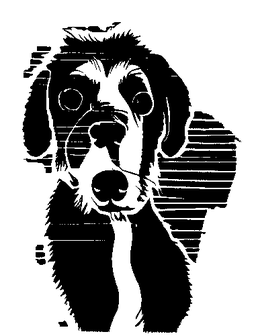


Dog / domestic_dog / left_profile


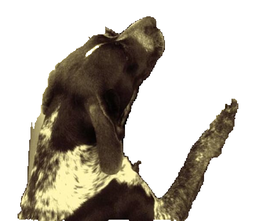

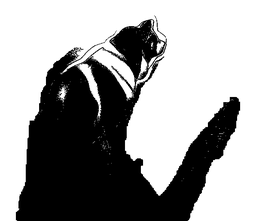


Cat / domestic_cat / left_profile


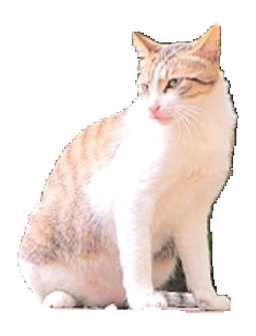

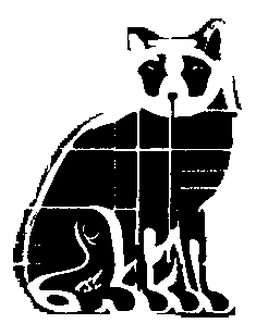


Cat / cat / front_right_3q


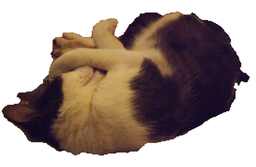

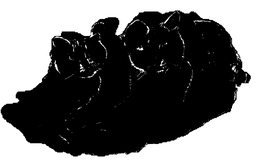


Horse / horse / left_profile


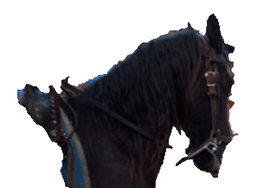

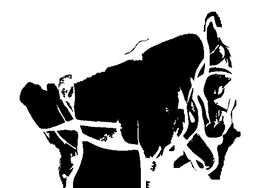


Dog / dog / left_profile


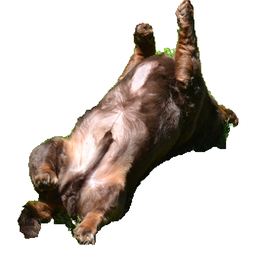

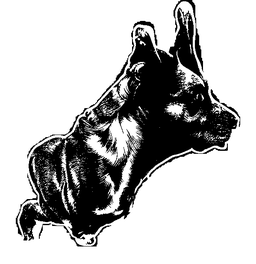

In [ ]:
# Show crop and its generated line diagram side-by-side for the first few subjects.
# This is the primary visual check after any changes to outline_generator settings.
subjects_by_id = {r['sample_id']: r for r in load_ndjson(
    REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'silver_subjects.ndjson'
)}

for attempt in diagram_attempt_rows[:6]:
    sid = attempt['sample_id']
    subj = subjects_by_id.get(sid)
    diagram_path = REPO_ROOT / attempt['diagram_path']
    label = f"{attempt.get('category','?')} / {attempt.get('subcategory','?')} / {attempt.get('angle_bucket','?')}"
    print(label)
    if subj and subj.get('crop_path'):
        crop = Image.open(REPO_ROOT / subj['crop_path'])
        display(crop.resize((256, int(256 * crop.height / max(crop.width, 1))), Image.Resampling.LANCZOS))
    if diagram_path.exists():
        diag = Image.open(diagram_path)
        display(diag.resize((256, int(256 * diag.height / max(diag.width, 1))), Image.Resampling.LANCZOS))
    print()


## Step 6: Validate And Retry Diagrams

In [ ]:
run_stage('validate_and_retry_diagrams.py')

validated_path = REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'validated_diagrams.ndjson'
validated_rows = load_ndjson(validated_path)
validated_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/validate_and_retry_diagrams.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


/home/shravan/Workspace/WildTrace/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1985.12it/s]
CLIPTextModel LOAD REPORT from: /home/shravan/.cache/huggingface/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 1482.98it/s]
StableDiffusionSafetyChecker LOAD REPORT from: /home/shravan/.cache/huggingface/models--runwayml--stable-diffusion-v1-5

[{'angle_bucket': 'left_profile',
  'category': 'Dog',
  'diagram_attempt': 5,
  'diagram_path': 'outputs/silver/line_diagrams/Dog/053f21d0244601a8_attempt05.png',
  'diagram_validation_score': 0.4526,
  'diagram_validation_status': 'rejected',
  'lineage': {'diagram_attempt_count': 4,
   'subject_sample_id': '053f21d0244601a8'},
  'opencv_flags': [],
  'outline_generator_backend': {'execution_mode': 'onnxruntime',
   'inference_params': {'input_size': 512,
    'line_threshold': 44,
    'max_outlines': 1,
    'min_component_area': 80,
    'outline_simplify_ratio': 0.7,
    'outline_stroke_width': 2,
    'postprocess_blur_radius': 2.0,
    'render_mode': 'informative_drawings',
    'silhouette_close_kernel': 3,
    'subject_threshold': 44},
   'model_backend': 'onnxruntime',
   'model_name': 'informative_drawings',
   'model_version_or_checkpoint': 'rocca/informative-drawings-line-art-onnx}/${INFORMATIVE_DRAWINGS_FILENAME:-model.onnx'},
  'outline_rectifier_backend': {'conditioning_sour

## Step 7: Select Final By Angle

In [ ]:
run_stage('select_final_by_angle.py')

selected_path = REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'selected_diagrams.ndjson'
selected_rows = load_ndjson(selected_path)
selected_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/select_final_by_angle.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


[{'angle_bucket': 'left_profile',
  'category': 'Cat',
  'diagram_attempt': 1,
  'diagram_path': 'outputs/silver/line_diagrams/Cat/0add6512b401d878_attempt01.png',
  'diagram_validation_score': 0.9177,
  'diagram_validation_status': 'accepted',
  'lineage': {'diagram_attempt_count': 1,
   'initial_attempt_hash': '3f3918556bf6dec9',
   'selection_source_hash': '1435a1dc53491447',
   'subject_sample_id': '0add6512b401d878',
   'validation_config_hash': 'efcc27ee5505193f'},
  'opencv_flags': [],
  'outline_generator_backend': {'execution_mode': 'onnxruntime',
   'inference_params': {'input_size': 512,
    'line_threshold': 26,
    'max_outlines': 2,
    'min_component_area': 80,
    'outline_simplify_ratio': 0.003,
    'outline_stroke_width': 4,
    'postprocess_blur_radius': 2.0,
    'render_mode': 'informative_drawings',
    'silhouette_close_kernel': 9,
    'subject_threshold': 248},
   'model_backend': 'onnxruntime',
   'model_name': 'informative_drawings',
   'model_version_or_checkp

## Step 8: Extract Trajectories & Export Gold

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/extract_trajectories.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs
Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/export_gold_ndjson.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs
gold records: 6


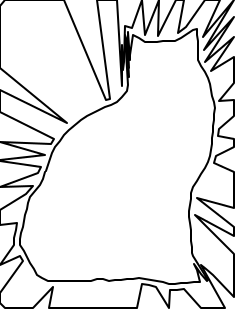

In [ ]:
run_stage('extract_trajectories.py')

run_stage('export_gold_ndjson.py')

gold_path = REPO_ROOT / 'outputs' / 'gold' / 'records' / 'gold_samples.ndjson'
gold_rows = load_ndjson(gold_path)
print(f'gold records: {len(gold_rows)}')
if gold_rows:
    first = gold_rows[0]
    display(SVG(filename=str(REPO_ROOT / first['gold_refs']['svg_path'])))
    first['trajectory']


## Step 9: Generate Dataset Report

In [ ]:
run_stage('generate_dataset_report.py')

report_json = REPO_ROOT / 'outputs' / 'reports' / 'dataset_report.json'
report_md = REPO_ROOT / 'outputs' / 'reports' / 'dataset_report.md'
print(report_json.read_text(encoding='utf-8'))
print('\n---\n')
print(report_md.read_text(encoding='utf-8'))

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/generate_dataset_report.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs
{
  "accepted_diagrams": 7,
  "angles": {
    "Cat::domestic_cat": {
      "left_profile": 1
    },
    "Dog::dog": {
      "left_profile": 1
    },
    "Dog::domestic_dog": {
      "left_profile": 1,
      "right_profile": 1
    },
    "Horse::horse": {
      "left_profile": 1,
      "right_profile": 1
    }
  },
  "bronze_accepted": 15,
  "bronze_curated": 50,
  "categories": {
    "Cat": {
      "selected": 1
    },
    "Dog": {
      "selected": 3
    },
    "Horse": {
      "selected": 2
    }
  },
  "generated_at": "2026-04-04T06:03:09.793529+00:00",
  "source_hash": "{\"curated\": [{\"angle_bucket\": \"left_profile\", \"angle_feasible\": true, \"category\": \"Dog\", \"curation_flags\": [], \"curation_status\": \"accepted\", \"deleted_paths\": [], \"imag